# 🔬 แกะ LLM ทีละชิ้น — จาก Tokenizer ถึง Chat Model

Notebook นี้เป็น **เล่มที่ 2** ต่อจาก `ML_Fundamentals.ipynb` (Part 7–8 ที่สร้าง mini GPT ระดับตัวอักษร)
คราวนี้เจาะลึกชิ้นส่วนรอบ ๆ ตัวโมเดล ที่ทำให้ LLM จริงทำงานได้ — โดยยังยึดหลักเดิม: **เขียนเองให้เห็นกลไกก่อน แล้วค่อยเชื่อมว่าของจริง scale ยังไง**

| Part | เนื้อหา | เขียนเอง / เครื่องมือ |
|---|---|---|
| 1 | **BPE Tokenizer** — เขียน Byte Pair Encoding จากศูนย์ | NumPy ล้วน |
| 2 | **Pretrain mini GPT v2** — train บน BPE token + ดู embedding ที่เรียนได้ | TensorFlow |
| 3 | **Sampling** — greedy / temperature / top-k / top-p ต่างกันยังไง | NumPy + กราฟ |
| 4 | **KV Cache** — ทำไม LLM generate ได้เร็ว (วัดเวลาจริง) | NumPy ล้วน |
| 5 | **Fine-tuning** — จาก base model สู่ผู้ช่วยตอบคำถาม + catastrophic forgetting | TensorFlow |
| 6 | **จากของเล่นสู่ Claude/GPT จริง** — RLHF, RAG, long context, agents | (แนวคิด) |

> **เส้นเรื่องของทั้งเล่ม:** LLM ที่ใช้งานจริงไม่ได้มีแค่ "โมเดล transformer"
> แต่เป็น **pipeline**: ข้อความ → tokenizer → โมเดล (pretrain แล้ว fine-tune) → กลยุทธ์ generate → ตอบกลับ
> เล่มนี้สร้างทุกชิ้นนั้นด้วยมือในสเกลจิ๋ว

In [1]:
# ── Setup ──────────────────────────────────────────────────────────
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # ปิด log ภายในของ TensorFlow (ตั้งก่อน import tf)

import time
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Tahoma"       # ฟอนต์ที่มีอักษรไทย (มากับ Windows)
plt.rcParams["axes.unicode_minus"] = False
np.random.seed(0)

---
## Part 1 — BPE Tokenizer: เขียน Byte Pair Encoding จากศูนย์

ก่อนข้อความจะเข้าโมเดลได้ ต้องแปลงเป็น **ตัวเลข (token id)** ก่อน — งานของ *tokenizer*

ใน mini GPT เล่มแรกเราใช้ **1 ตัวอักษร = 1 token** ซึ่งง่ายแต่เปลือง: คำว่า `"the"` ใช้ตั้ง 3 token
LLM จริงเกือบทั้งหมด (GPT, Claude, Llama) ใช้ **subword tokenization** แบบ **BPE** ที่อยู่กึ่งกลาง:
คำที่เจอบ่อยกลายเป็น token เดียว ส่วนคำแปลก ๆ ค่อยแตกเป็นชิ้นเล็ก

**อัลกอริทึม BPE เรียบง่ายมาก** — แค่วนทำ 3 ขั้นนี้ซ้ำ ๆ:

1. นับว่า **คู่ token ที่อยู่ติดกัน** คู่ไหนเจอบ่อยที่สุด
2. **รวม (merge)** คู่นั้นให้เป็น token ใหม่ 1 ตัว
3. วนกลับไปข้อ 1 จนกว่าจะได้ vocab ขนาดที่ต้องการ

เริ่มจากชุดข้อความ (corpus) เล็ก ๆ — นิทานสัตว์ที่จะใช้ตลอดทั้งเล่ม:

In [2]:
# ── corpus: ใช้ตลอดทั้งเล่ม (pretrain ใน Part 2, fine-tune ใน Part 5) ──

# ข้อความเล่าเรื่อง — โครงสร้างซ้ำพอให้โมเดลจิ๋วเรียนรู้ได้บน CPU
pretrain_unit = """the quick fox lived in the green wood.
one day the quick fox saw a slow hen near the old barn.
the fox said: i am quick and you are slow.
the hen said: but i can see the wolf and you can not.
why did the fox run to the wood? because the wolf came to the barn.
the wolf was big and grey. the wolf ate the corn but not the hen.
the hen hid in the barn. the fox hid in the wood. the wolf slept.
the small cat sat on the warm mat in the sun.
the old dog slept on the cold log by the door.
who is at the door? the small cat is at the door.
the cat saw a red bird in the tall tree.
the dog saw the cat and the cat saw the dog.
the bird flew from the tall tree to the old barn.
the cat ran to the tree. the dog ran to the barn. the bird flew away.
the moon rose over the green wood and the old barn.
the fox and the hen and the cat and the dog slept.
the night was long and the wood was dark and still.
all was well in the wood. all was well in the barn.
"""
corpus = pretrain_unit * 6      # ทำซ้ำเพื่อให้มีข้อมูลพอ train

# corpus รูปแบบถาม-ตอบ — เก็บไว้ fine-tune ใน Part 5 (อักษรอยู่ในชุดเดียวกับด้านบน)
qa_unit = """q: who lived in the green wood? a: the quick fox lived in the green wood.
q: what did the cat see? a: the cat saw a red bird in the tall tree.
q: who is at the door? a: the small cat is at the door.
q: why did the fox run to the wood? a: because the wolf came to the barn.
q: what did the wolf eat? a: the wolf ate the corn but not the hen.
q: where did the hen hide? a: the hen hid in the barn.
q: who slept on the cold log? a: the old dog slept on the cold log by the door.
q: where did the bird fly? a: the bird flew from the tall tree to the old barn.
"""
qa_corpus = qa_unit * 6

print(f"pretrain corpus: {len(corpus):,} ตัวอักษร")
print(f"จำนวนอักษรไม่ซ้ำ: {len(set(corpus))} ตัว -> {''.join(sorted(set(corpus)))!r}")

pretrain corpus: 5,688 ตัวอักษร
จำนวนอักษรไม่ซ้ำ: 29 ตัว -> '\n .:?abcdefghiklmnopqrstuvwxy'


In [3]:
# ── หัวใจของ BPE: นับคู่ที่เจอบ่อย แล้ว merge ──

def get_pair_counts(ids):
    """นับว่าคู่ token ติดกันแต่ละคู่ปรากฏกี่ครั้ง"""
    counts = {}
    for a, b in zip(ids, ids[1:]):
        counts[(a, b)] = counts.get((a, b), 0) + 1
    return counts

def merge_pair(ids, pair, new_id):
    """แทนที่ทุกครั้งที่เจอ pair ติดกัน ด้วย token ใหม่ 1 ตัว"""
    out, i = [], 0
    while i < len(ids):
        if i < len(ids) - 1 and (ids[i], ids[i + 1]) == pair:
            out.append(new_id)      # เจอคู่ -> ยุบเป็น token เดียว
            i += 2
        else:
            out.append(ids[i])
            i += 1
    return out

# เริ่มจาก vocab = ตัวอักษรเดี่ยว ๆ (เหมือน char-level)
base_chars = sorted(set(corpus))
stoi = {c: i for i, c in enumerate(base_chars)}     # char -> id
vocab = {i: c for i, c in enumerate(base_chars)}    # id -> ข้อความที่ token นั้นแทน

NUM_MERGES = 60                                     # จำนวน token ใหม่ที่จะสร้าง
ids = [stoi[c] for c in corpus]
merges = []                                         # ลำดับการ merge (ต้องใช้ตอน encode ข้อความใหม่)

for step in range(NUM_MERGES):
    counts = get_pair_counts(ids)
    best_pair = max(counts, key=counts.get)         # ขั้น 1: คู่ที่เจอบ่อยสุด
    new_id = len(vocab)
    vocab[new_id] = vocab[best_pair[0]] + vocab[best_pair[1]]   # ขั้น 2: สร้าง token ใหม่
    merges.append((best_pair, new_id))
    ids = merge_pair(ids, best_pair, new_id)         # ขั้น 3: ใช้ token ใหม่ทับใน corpus

print(f"vocab: {len(base_chars)} อักษรเดี่ยว -> {len(vocab)} token หลัง merge {NUM_MERGES} ครั้ง\n")
print("10 token แรกที่ BPE สร้าง (เรียงตามความถี่):")
for (pair, nid) in merges[:10]:
    print(f"  รวม {vocab[pair[0]]!r} + {vocab[pair[1]]!r}  ->  {vocab[nid]!r}")

vocab: 29 อักษรเดี่ยว -> 89 token หลัง merge 60 ครั้ง

10 token แรกที่ BPE สร้าง (เรียงตามความถี่):
  รวม 'e' + ' '  ->  'e '
  รวม 't' + 'h'  ->  'th'
  รวม 'th' + 'e '  ->  'the '
  รวม ' ' + 'the '  ->  ' the '
  รวม ' ' + 'a'  ->  ' a'
  รวม '.' + '\n'  ->  '.\n'
  รวม 'd' + ' '  ->  'd '
  รวม '.\n' + 'the '  ->  '.\nthe '
  รวม 'n' + ' '  ->  'n '
  รวม 'w' + 'o'  ->  'wo'


In [4]:
# ── encode / decode + วัดผลการบีบอัด ──

def encode(text):
    """ข้อความ -> รายการ token id  (ใช้ merge ตามลำดับที่เรียนมา)"""
    out = [stoi[c] for c in text]
    for pair, new_id in merges:
        out = merge_pair(out, pair, new_id)
    return out

def decode(token_ids):
    """รายการ token id -> ข้อความ"""
    return "".join(vocab[i] for i in token_ids)

# ตรวจว่า encode แล้ว decode กลับได้ข้อความเดิมเป๊ะ
assert decode(encode(pretrain_unit)) == pretrain_unit, "roundtrip ผิด!"

n_char = len(corpus)
n_tok = len(encode(corpus))
print(f"char-level: {n_char:,} token    vs   BPE: {n_tok:,} token   =  สั้นลง {n_char / n_tok:.2f} เท่า\n")

# คำที่ 'เจอบ่อย' กลายเป็น token เดียว แต่คำแปลก ๆ ยังแตกเป็นชิ้น
for word in ["the quick fox ", "strawberry"]:
    toks = [vocab[i] for i in encode(word)]
    print(f"{word!r:18} -> {len(toks)} token: {toks}")

print("\n💡 ทำไม LLM ชอบตอบผิดว่า 'strawberry' มี r กี่ตัว?")
print("   เพราะมันไม่เคยเห็นเป็นตัวอักษร — มันเห็นเป็นก้อน subword อย่างข้างบน")
print("   การนับตัวอักษรในก้อนที่ตัวเองไม่เคยถูกสอนให้แยก จึงเป็นงานที่ผิดธรรมชาติของมัน")

char-level: 5,688 token    vs   BPE: 2,228 token   =  สั้นลง 2.55 เท่า

'the quick fox '   -> 4 token: ['the ', 'quick', ' ', 'fox ']
'strawberry'       -> 9 token: ['s', 't', 'r', 'aw', 'b', 'e', 'r', 'r', 'y']

💡 ทำไม LLM ชอบตอบผิดว่า 'strawberry' มี r กี่ตัว?
   เพราะมันไม่เคยเห็นเป็นตัวอักษร — มันเห็นเป็นก้อน subword อย่างข้างบน
   การนับตัวอักษรในก้อนที่ตัวเองไม่เคยถูกสอนให้แยก จึงเป็นงานที่ผิดธรรมชาติของมัน


---
## Part 2 — Pretrain mini GPT v2 บน BPE Token

ตอนนี้มี tokenizer แล้ว เอา GPT มาเทรนบน token เหล่านั้น **สถาปัตยกรรมเหมือนเล่มแรกเป๊ะ**
(token + positional embedding → transformer block ที่มี causal self-attention → output head)
ต่างแค่ป้อน **BPE token** แทนตัวอักษร และ vocab ใหญ่ขึ้น

**Pretraining** = สอนโจทย์เดียวล้วน ๆ: *ทาย token ถัดไป* บนข้อความดิบจำนวนมหาศาล
นี่คือขั้นที่โมเดลเรียน "ความรู้เรื่องภาษาและโลก" ทั้งหมด (ของจริงใช้ข้อความเกือบทั้งอินเทอร์เน็ต)

In [5]:
# ── สถาปัตยกรรม GPT (เหมือนเล่มแรก) ──
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.get_logger().setLevel("ERROR")

vocab_size = len(vocab)
SEQ_LEN  = 32     # context window (token)
D_MODEL  = 128    # ขนาดเวกเตอร์ต่อ token
N_HEADS  = 4      # จำนวนหัว attention
FF_DIM   = 256    # ขนาด hidden ของ feed-forward
N_BLOCKS = 2      # จำนวน transformer block

class TokenAndPositionEmbedding(layers.Layer):
    """รวม 'token นี้คืออะไร' + 'อยู่ตำแหน่งไหน' (เหมือนเล่มแรก)"""
    def __init__(self, maxlen, vocab_size, d_model):
        super().__init__()
        self.token_emb = layers.Embedding(vocab_size, d_model)
        self.pos_emb   = layers.Embedding(maxlen, d_model)
    def call(self, x):
        return self.token_emb(x) + self.pos_emb(tf.range(tf.shape(x)[-1]))

class TransformerBlock(layers.Layer):
    """causal self-attention + feed-forward พร้อม residual + LayerNorm"""
    def __init__(self, d_model, n_heads, ff_dim):
        super().__init__()
        self.attn = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model // n_heads)
        self.ffn = keras.Sequential([layers.Dense(ff_dim, activation="relu"),
                                     layers.Dense(d_model)])
        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()
    def call(self, x):
        x = self.norm1(x + self.attn(x, x, use_causal_mask=True))   # ห้ามมองอนาคต
        return self.norm2(x + self.ffn(x))

def build_gpt():
    """สร้างโมเดลใหม่ (seed คงที่ -> reproducible)"""
    keras.utils.set_random_seed(42)
    inp = keras.Input(shape=(None,), dtype="int32")
    x = TokenAndPositionEmbedding(SEQ_LEN, vocab_size, D_MODEL)(inp)
    for _ in range(N_BLOCKS):
        x = TransformerBlock(D_MODEL, N_HEADS, FF_DIM)(x)
    return keras.Model(inp, layers.Dense(vocab_size)(x))

def make_windows(token_ids, seq_len=SEQ_LEN):
    """ตัด token เป็นคู่ (input, target ที่เลื่อนไป 1 ตำแหน่ง) สำหรับโจทย์ทายตัวถัดไป"""
    arr = np.asarray(token_ids, dtype=np.int32)
    X = np.array([arr[i:i+seq_len]     for i in range(len(arr) - seq_len - 1)])
    Y = np.array([arr[i+1:i+seq_len+1] for i in range(len(arr) - seq_len - 1)])
    return X, Y

X_pre, Y_pre = make_windows(encode(corpus))
print(f"ชุด pretrain: {X_pre.shape[0]:,} ตัวอย่าง, ยาวตัวอย่างละ {SEQ_LEN} token")

ชุด pretrain: 2,195 ตัวอย่าง, ยาวตัวอย่างละ 32 token


train เสร็จใน 38s | loss 1.460 -> 0.0690


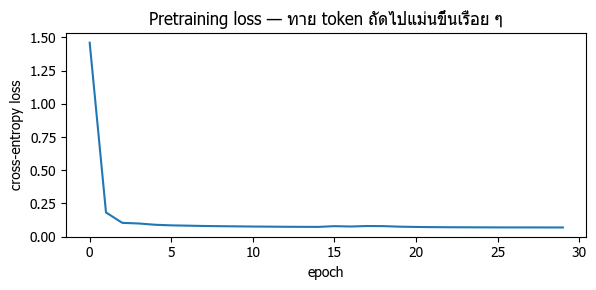

In [6]:
# ── pretrain: ทาย token ถัดไป ──
base_model = build_gpt()
base_model.compile(optimizer=keras.optimizers.Adam(3e-3),
                   loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True))

t0 = time.time()
hist = base_model.fit(X_pre, Y_pre, batch_size=64, epochs=30, verbose=0)
print(f"train เสร็จใน {time.time()-t0:.0f}s | "
      f"loss {hist.history['loss'][0]:.3f} -> {hist.history['loss'][-1]:.4f}")

plt.figure(figsize=(6, 3))
plt.plot(hist.history["loss"])
plt.xlabel("epoch"); plt.ylabel("cross-entropy loss")
plt.title("Pretraining loss — ทาย token ถัดไปแม่นขึ้นเรื่อย ๆ")
plt.tight_layout(); plt.show()

In [7]:
# ── ดูว่าโมเดลเรียนรู้อะไร: ลอง generate แบบ greedy (เลือกตัวที่มั่นใจสุดเสมอ) ──

def generate(model, prompt, n_tokens=60, strategy="greedy",
             temperature=1.0, k=5, p=0.9, seed=0):
    """generate ต่อจาก prompt — รองรับหลายกลยุทธ์ (ใช้เต็มที่ใน Part 3)"""
    rng = np.random.default_rng(seed)
    ids_out = encode(prompt)
    for _ in range(n_tokens):
        logits = model(np.array([ids_out[-SEQ_LEN:]]), training=False).numpy()[0, -1]
        ids_out.append(sample_from_logits(logits, strategy, temperature, k, p, rng))
    return decode(ids_out)

def sample_from_logits(logits, strategy="greedy", temperature=1.0, k=5, p=0.9, rng=None):
    if strategy == "greedy":
        return int(np.argmax(logits))                  # เลือกตัวที่ logits สูงสุดเสมอ
    probs = _softmax(logits / temperature)
    if strategy == "top_k":
        keep = np.argsort(probs)[::-1][:k]
        probs = _mask_to(probs, keep)
    elif strategy == "top_p":
        order = np.argsort(probs)[::-1]
        cutoff = int(np.searchsorted(np.cumsum(probs[order]), p)) + 1
        probs = _mask_to(probs, order[:cutoff])
    return int(rng.choice(len(probs), p=probs))

def _softmax(x):
    e = np.exp(x - x.max()); return e / e.sum()

def _mask_to(probs, keep_idx):
    """เก็บเฉพาะ token ใน keep_idx แล้ว normalize ใหม่ให้รวมเป็น 1"""
    m = np.zeros_like(probs); m[keep_idx] = probs[keep_idx]
    return m / m.sum()

print(generate(base_model, "the quick fox ", n_tokens=70, strategy="greedy"))

the quick fox lived in the green wood.
one day the quick fox saw a slow hen near the old barn.
the fox said: i am quick and you are slow.
the hen said: but i can se


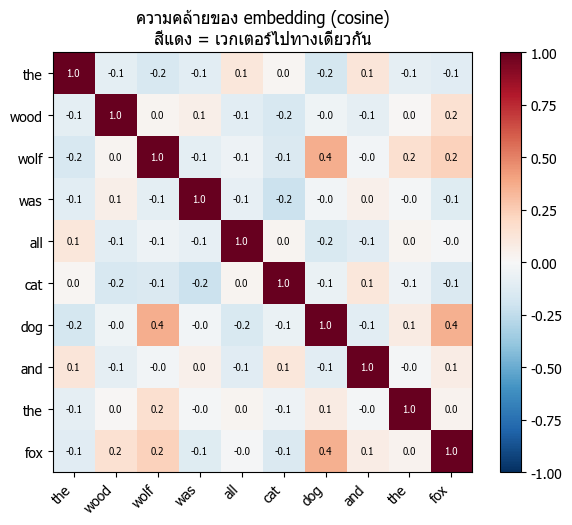

โมเดลจิ๋วนี้เพิ่งเริ่มเห็นเค้าโครง — กลุ่มชื่อสัตว์มักได้เวกเตอร์คล้ายกันมากกว่าคำอื่น


In [8]:
# ── โบนัส: embedding ที่โมเดลเรียนได้ — token ที่ความหมายใกล้กัน เวกเตอร์ก็ใกล้กัน ──

emb = base_model.layers[1].token_emb.get_weights()[0]      # (vocab_size, D_MODEL)
emb_norm = emb / np.linalg.norm(emb, axis=1, keepdims=True)
sim = emb_norm @ emb_norm.T                                # cosine similarity ทุกคู่

# เลือกเฉพาะ token ที่เป็น "คำเต็ม" (อักษรล้วน ยาว >= 3) ที่เจอบ่อยสุด
counts = np.bincount(np.array(encode(corpus)), minlength=vocab_size)
word_tokens = [i for i in range(vocab_size)
               if vocab[i].strip().isalpha() and len(vocab[i].strip()) >= 3]
word_tokens = sorted(word_tokens, key=lambda i: -counts[i])[:10]
labels = [vocab[i].strip() for i in word_tokens]
sub = sim[np.ix_(word_tokens, word_tokens)]

fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(sub, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)
ax.set_title("ความคล้ายของ embedding (cosine)\nสีแดง = เวกเตอร์ไปทางเดียวกัน")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{sub[i,j]:.1f}", ha="center", va="center", fontsize=7,
                color="white" if abs(sub[i,j]) > 0.6 else "black")
plt.colorbar(im); plt.tight_layout(); plt.show()
print("โมเดลจิ๋วนี้เพิ่งเริ่มเห็นเค้าโครง — กลุ่มชื่อสัตว์มักได้เวกเตอร์คล้ายกันมากกว่าคำอื่น")

---
## Part 3 — Sampling: เลือก Token ถัดไปอย่างไร

ทุกครั้งที่โมเดล generate มันให้ **logits** = คะแนนของ token ถัดไป *ทุกตัว* ใน vocab
จากนั้น softmax แปลงเป็น **การแจกแจงความน่าจะเป็น** แล้วเราต้อง "เลือก" 1 token ออกมา — วิธีเลือกนี่แหละคือ *sampling strategy*

| กลยุทธ์ | ทำอะไร | บุคลิกผลลัพธ์ |
|---|---|---|
| **Greedy** | เลือกตัวที่น่าจะเป็นสูงสุดเสมอ | นิ่ง แน่นอน แต่ซ้ำซากและวนลูปง่าย |
| **Temperature** | หาร logits ด้วย T ก่อน softmax | T ต่ำ = มั่นใจ/น่าเบื่อ, T สูง = หลากหลาย/มั่ว |
| **Top-k** | เก็บเฉพาะ k ตัวที่น่าจะเป็นสูงสุด แล้วสุ่ม | กันคำที่แย่สุดออก คุมคุณภาพ |
| **Top-p (nucleus)** | เก็บตัวที่สะสมความน่าจะเป็นถึง p แล้วสุ่ม | ปรับจำนวนตัวเลือกอัตโนมัติตามความมั่นใจ |

วิธีเห็นภาพดีที่สุดคือดูว่าแต่ละกลยุทธ์ **"ตัด" การแจกแจงเดียวกัน**ต่างกันยังไง
สมมติโมเดลกำลังเติมประโยค *"the weather today is ___"* แล้วให้การแจกแจงนี้:

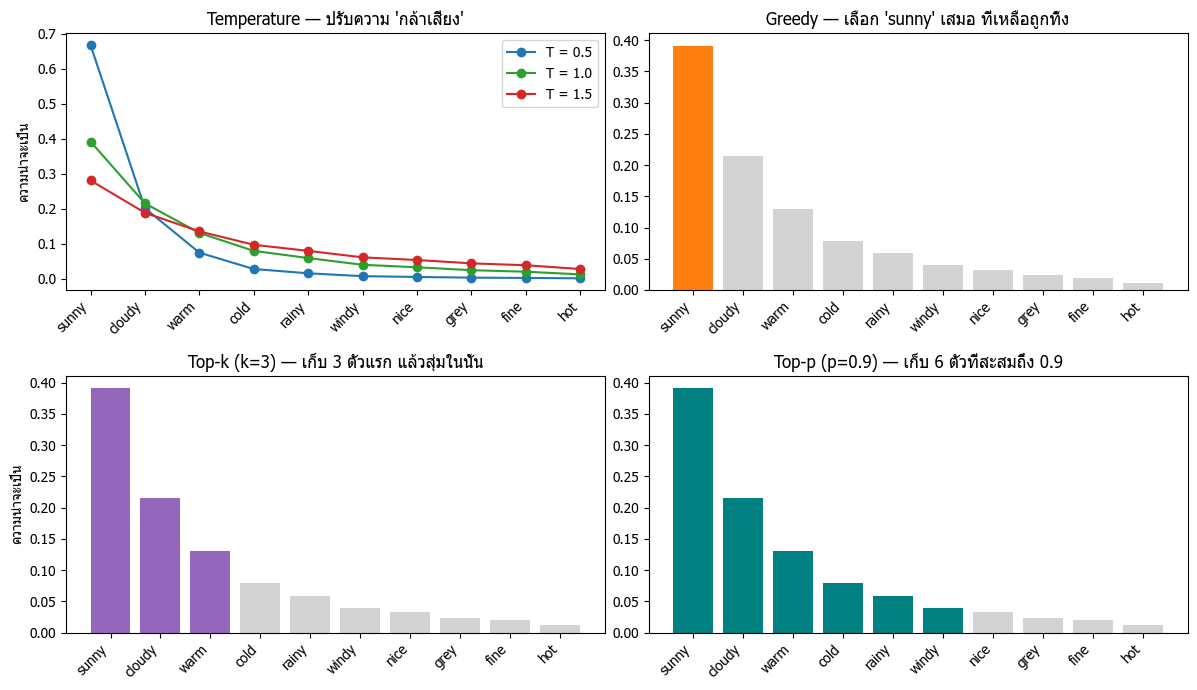

Top-k เก็บคงที่ 3 ตัว เสมอ | Top-p ปรับเอง: รอบนี้ได้ 6 ตัว (ถ้าโมเดลมั่นใจมากจะเก็บน้อยลงอัตโนมัติ)


In [9]:
# ── เทียบ 4 กลยุทธ์บนการแจกแจงตัวอย่างเดียวกัน ──
candidates = ["sunny", "cloudy", "warm", "cold", "rainy", "windy", "nice", "grey", "fine", "hot"]
demo_logits = np.array([3.2, 2.6, 2.1, 1.6, 1.3, 0.9, 0.7, 0.4, 0.2, -0.3])

def softmax_T(logits, T=1.0):
    z = logits / T; e = np.exp(z - z.max()); return e / e.sum()

base_probs = softmax_T(demo_logits)
xs = np.arange(len(candidates))

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# (1) Temperature — ยิ่ง T สูง การแจกแจงยิ่งแบน (สุ่มหลากหลายขึ้น)
ax = axes[0, 0]
for T, color in [(0.5, "tab:blue"), (1.0, "tab:green"), (1.5, "tab:red")]:
    ax.plot(xs, softmax_T(demo_logits, T), "o-", color=color, label=f"T = {T}")
ax.set_title("Temperature — ปรับความ 'กล้าเสี่ยง'")
ax.legend(); ax.set_xticks(xs, candidates, rotation=45, ha="right")
ax.set_ylabel("ความน่าจะเป็น")

# (2) Greedy — เลือกตัวสูงสุดตัวเดียว (ความน่าจะเป็นที่เหลือถูกทิ้งหมด)
ax = axes[0, 1]
colors = ["tab:orange" if i == base_probs.argmax() else "lightgrey" for i in xs]
ax.bar(xs, base_probs, color=colors)
ax.set_title("Greedy — เลือก 'sunny' เสมอ ที่เหลือถูกทิ้ง")
ax.set_xticks(xs, candidates, rotation=45, ha="right")

# (3) Top-k = 3 — เก็บ 3 ตัวแรก
ax = axes[1, 0]
k = 3
keep_k = set(np.argsort(base_probs)[::-1][:k])
colors = ["tab:purple" if i in keep_k else "lightgrey" for i in xs]
ax.bar(xs, base_probs, color=colors)
ax.set_title(f"Top-k (k={k}) — เก็บ {k} ตัวแรก แล้วสุ่มในนั้น")
ax.set_xticks(xs, candidates, rotation=45, ha="right")
ax.set_ylabel("ความน่าจะเป็น")

# (4) Top-p = 0.9 — เก็บจนความน่าจะเป็นสะสมถึง 0.9
ax = axes[1, 1]
p = 0.9
order = np.argsort(base_probs)[::-1]
cutoff = int(np.searchsorted(np.cumsum(base_probs[order]), p)) + 1
keep_p = set(order[:cutoff])
colors = ["teal" if i in keep_p else "lightgrey" for i in xs]
ax.bar(xs, base_probs, color=colors)
ax.set_title(f"Top-p (p={p}) — เก็บ {cutoff} ตัวที่สะสมถึง {p}")
ax.set_xticks(xs, candidates, rotation=45, ha="right")

plt.tight_layout(); plt.show()
print(f"Top-k เก็บคงที่ {k} ตัว เสมอ | Top-p ปรับเอง: รอบนี้ได้ {cutoff} ตัว "
      f"(ถ้าโมเดลมั่นใจมากจะเก็บน้อยลงอัตโนมัติ)")

### ลองกับโมเดลจริง — และข้อสังเกตสำคัญ

นำกลยุทธ์เหล่านี้ไปใช้กับ `base_model` ที่เพิ่ง pretrain เสร็จ

In [10]:
# ── generate ด้วยกลยุทธ์ต่าง ๆ จาก prompt เดียวกัน ──
prompt = "the fox "
print(f"prompt: {prompt!r}\n" + "=" * 70)
for label, kw in [
    ("greedy",            dict(strategy="greedy")),
    ("temperature = 0.5", dict(strategy="temperature", temperature=0.5)),
    ("temperature = 1.5", dict(strategy="temperature", temperature=1.5)),
    ("top_k = 5",         dict(strategy="top_k", k=5, temperature=1.0)),
    ("top_p = 0.9",       dict(strategy="top_p", p=0.9, temperature=1.0)),
]:
    text = generate(base_model, prompt, n_tokens=45, seed=1, **kw)
    print(f"\n[{label}]\n{text}")

# วัดความ 'มั่นใจ' ของโมเดล ณ จุดหนึ่ง ด้วย entropy (ต่ำ = มั่นใจมาก)
logits = base_model(np.array([encode("the ")]), training=False).numpy()[0, -1]
probs = _softmax(logits)
entropy = -np.sum(probs * np.log(probs + 1e-12))
top = np.argsort(probs)[::-1][:3]
print("\n" + "=" * 70)
print(f"หลังคำว่า 'the ' โมเดลมั่นใจมาก (entropy {entropy:.2f}): "
      + ", ".join(f"{vocab[i].strip()!r} {probs[i]:.0%}" for i in top))

prompt: 'the fox '



[greedy]
the fox hid in the wood. the wolf slept.
the small cat sat on the warm mat in the sun.
the old dog slept on the cold log b



[temperature = 0.5]
the fox hid in the wood. the wolf slept.
the small cat sat on the warm mat in the sun.
the old dog slept on the cold log b



[temperature = 1.5]
the fox hy was long and the wood was dark and still.
all was well in the wood. all was well in the barn.
the quick fox lived in the gre



[top_k = 5]
the fox hid in the wood. the wolf slept.
the small cat sat on the warm mat in the sun.
the old dog slept on the cold log b



[top_p = 0.9]
the fox hid in the wood. the wolf slept.
the small cat sat on the warm mat in the sun.
the old dog slept on the cold log b

หลังคำว่า 'the ' โมเดลมั่นใจมาก (entropy 0.42): 'wolf' 91%, 'c' 5%, 'quick' 3%


> **ข้อสังเกต:** ที่ temperature ต่ำ–ปานกลาง ผลลัพธ์เกือบเหมือน greedy หมด
> เพราะโมเดลจิ๋วของเรา train บน corpus เล็กที่ซ้ำมาก จน **การแจกแจงแหลมเกือบ 100% แทบทุกตำแหน่ง** (entropy ต่ำมาก)
> — sampling strategy จะมีผลก็ต่อเมื่อ **โมเดลไม่มั่นใจ** เท่านั้น
>
> นี่คือเหตุผลที่ความต่างเริ่มเห็นชัดที่ T = 1.5 (ดันให้มันกล้าเสี่ยงพอจะหลุดจากเส้นทางที่ท่องจำไว้)
> ส่วน LLM จริงที่ train บนข้อมูลหลากหลายมหาศาล จะ "ไม่มั่นใจ" ที่หลายจุด — knob เหล่านี้จึงสำคัญมากในทางปฏิบัติ
> (เวลาเรียก API ของ Claude/GPT พารามิเตอร์ `temperature`, `top_p` ก็คือตัวเดียวกันนี้)

---
## Part 4 — KV Cache: ทำไม LLM ถึง Generate ได้เร็ว

ตอน generate โมเดลทำงาน **autoregressive**: ทาย 1 token → ต่อท้าย → ทายตัวถัดไป วนไปเรื่อย ๆ

ปัญหา: ทุกครั้งที่ทาย token ใหม่ self-attention ต้องใช้ **Key (K)** และ **Value (V)** ของ *ทุก token ก่อนหน้า*
ถ้าคำนวณ K, V ของ context เดิมใหม่หมดทุกก้าว งานจะซ้ำซ้อนมหาศาล (token ที่ 100 ต้องคำนวณ token 1–99 ใหม่อีกครั้ง)

**ทางออกคือ KV Cache:** K กับ V ของ token เดิม**ไม่เคยเปลี่ยน** → คำนวณครั้งเดียวแล้ว**เก็บไว้**
แต่ละก้าวคำนวณ K, V แค่ของ token *ใหม่ตัวเดียว* แล้วต่อเข้า cache

มาวัดเวลาจริงด้วย self-attention เขียนเองใน NumPy (single head เพื่อความชัด):

In [11]:
# ── เทียบความเร็ว: คำนวณใหม่ทุกก้าว vs ใช้ KV cache ──
rng = np.random.default_rng(0)
d = 64                                  # ขนาดเวกเตอร์ต่อ token
W_Q, W_K, W_V = (rng.standard_normal((d, d)) / np.sqrt(d) for _ in range(3))
GEN_LEN = 300                           # จำนวน token ที่จะ generate
x_start = rng.standard_normal(d)        # token เริ่มต้น

def softmax_rows(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True)); return e / e.sum(axis=-1, keepdims=True)

# ---------- วิธีที่ 1: ไม่มี cache — คำนวณ K, V ของทุก token ใหม่ทุกก้าว ----------
t0 = time.time()
seq = [x_start]
for _ in range(GEN_LEN):
    Xs = np.array(seq)                  # (t, d)  context ทั้งหมด ณ ตอนนี้
    Q, K, V = Xs @ W_Q, Xs @ W_K, Xs @ W_V        # คำนวณใหม่หมดทุกก้าว <- งานซ้ำ
    scores = Q @ K.T / np.sqrt(d)
    scores = np.where(np.triu(np.ones_like(scores), 1).astype(bool), -np.inf, scores)
    out_naive = (softmax_rows(scores) @ V)[-1]    # เอาเฉพาะแถวสุดท้าย (token ใหม่)
    seq.append(np.tanh(out_naive))
naive_time = time.time() - t0

# ---------- วิธีที่ 2: KV cache — เก็บ K, V เดิมไว้ คำนวณเฉพาะ token ใหม่ ----------
t0 = time.time()
seq = [x_start]
K_cache, V_cache = [], []
for _ in range(GEN_LEN):
    x_new = seq[-1]
    q = x_new @ W_Q
    K_cache.append(x_new @ W_K)         # คำนวณ K, V ของ 'token ใหม่ตัวเดียว' แล้วเก็บ
    V_cache.append(x_new @ W_V)
    scores = np.array(K_cache) @ q / np.sqrt(d)   # query ใหม่ เทียบ key เดิมทั้งหมดใน cache
    weights = _softmax(scores)
    out_cached = weights @ np.array(V_cache)
    seq.append(np.tanh(out_cached))
cached_time = time.time() - t0

print(f"generate {GEN_LEN} token:")
print(f"  ไม่มี cache : {naive_time*1000:6.0f} ms")
print(f"  KV cache    : {cached_time*1000:6.0f} ms")
print(f"  -> เร็วขึ้น {naive_time / cached_time:.1f} เท่า (ผลลัพธ์เหมือนกันเป๊ะ ไม่ใช่การประมาณ)")
print(f"  ยิ่ง context ยาว ส่วนต่างยิ่งถ่างออก (งานซ้ำโตแบบ O(n²) เทียบกับ O(n))")

generate 300 token:
  ไม่มี cache :    263 ms
  KV cache    :     21 ms
  -> เร็วขึ้น 12.5 เท่า (ผลลัพธ์เหมือนกันเป๊ะ ไม่ใช่การประมาณ)
  ยิ่ง context ยาว ส่วนต่างยิ่งถ่างออก (งานซ้ำโตแบบ O(n²) เทียบกับ O(n))


---
## Part 5 — Fine-tuning: จาก Base Model สู่ผู้ช่วยตอบคำถาม

`base_model` ที่ pretrain มา "รู้ภาษา" ของนิทาน แต่มันทำได้แค่ **เล่าเรื่องต่อ** ไม่ได้ตอบคำถาม
ถ้าป้อน `"q: who is at the door? a:"` มันจะเล่านิทานต่อเฉย ๆ ไม่เข้าใจว่าเราอยากได้คำตอบ

**Fine-tuning** = เอาโมเดลที่ pretrain แล้วมา**เทรนต่อ**บนข้อมูลรูปแบบเฉพาะ (ที่นี่คือคู่ถาม-ตอบ `q: ... a: ...`)
ด้วย **learning rate ต่ำ** เพื่อปรับพฤติกรรมโดยไม่ลบความรู้เดิมทิ้ง

นี่คือหลักการเดียวกับที่เปลี่ยน "base model" ให้เป็น "chat model" อย่าง Claude หรือ ChatGPT
(ของจริงเรียก *instruction tuning* + *RLHF* — ซับซ้อนกว่านี้มาก แต่แก่นคือ "เทรนต่อให้ทำตามรูปแบบที่ต้องการ")

In [12]:
# ── fine-tune base_model บนคู่ถาม-ตอบ ──
X_qa, Y_qa = make_windows(encode(qa_corpus))
print(f"ชุด fine-tune (Q&A): {X_qa.shape[0]:,} ตัวอย่าง")

ft_model = build_gpt()                      # สร้างโครงเดิม
ft_model(np.zeros((1, 4), dtype=np.int32))  # เรียกครั้งหนึ่งเพื่อสร้าง weight
ft_model.set_weights(base_model.get_weights())   # ★ เริ่มจาก weight ของ base (ไม่เริ่มจากศูนย์)

ft_model.compile(optimizer=keras.optimizers.Adam(5e-4),   # LR ต่ำกว่า pretrain 6 เท่า
                 loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True))
t0 = time.time()
ft_model.fit(X_qa, Y_qa, batch_size=64, epochs=15, verbose=0)
print(f"fine-tune เสร็จใน {time.time()-t0:.0f}s")

ชุด fine-tune (Q&A): 1,605 ตัวอย่าง


fine-tune เสร็จใน 19s


In [13]:
# ── เทียบ base vs fine-tuned บนคำถามเดียวกัน ──
def ask(model, question, n_tokens=22):
    """ป้อนคำถามรูปแบบ 'q: ... a:' แล้วตัดเอาเฉพาะบรรทัดแรกของคำตอบ"""
    out = generate(model, question, n_tokens=n_tokens, strategy="greedy")
    return out[len(question):].split("\n")[0].strip()

print("─" * 72)
print("คำถามที่อยู่ในชุด fine-tune:")
for q in ["q: who is at the door? a:", "q: what did the wolf eat? a:"]:
    print(f"\n  {q}")
    print(f"    base       : {ask(base_model, q)!r}")
    print(f"    fine-tuned : {ask(ft_model, q)!r}   ✓")

print("\n" + "─" * 72)
print("คำถามใหม่ (ไม่เคยเห็นตอน fine-tune) — ดูว่ายังตอบ 'เป็นรูปแบบ' ไหม:")
for q in ["q: what did the dog see? a:", "q: where did the fox hide? a:"]:
    print(f"\n  {q}")
    print(f"    base       : {ask(base_model, q)!r}")
    print(f"    fine-tuned : {ask(ft_model, q)!r}")
print("\n→ base เล่านิทานต่อแบบไม่สนคำถาม | fine-tuned จับรูปแบบ 'ตอบสั้น ๆ จบประโยค' ได้")
print("  (คำตอบคำถามใหม่อาจไม่ถูกข้อเท็จจริง เพราะโมเดลจิ๋วเกินจะ 'เข้าใจ' จริง — แต่ 'รูปแบบ' มาแล้ว)")

────────────────────────────────────────────────────────────────────────
คำถามที่อยู่ในชุด fine-tune:

  q: who is at the door? a:


    base       : 'buse slow.'


    fine-tuned : 'the small cat is at the door.'   ✓

  q: what did the wolf eat? a:


    base       : 'buse the wolf came to the barn.'


    fine-tuned : 'the wolf ate the corn but not the hen.'   ✓

────────────────────────────────────────────────────────────────────────
คำถามใหม่ (ไม่เคยเห็นตอน fine-tune) — ดูว่ายังตอบ 'เป็นรูปแบบ' ไหม:

  q: what did the dog see? a:


    base       : 'quick and you are slow.'


    fine-tuned : 'the hen hid in the barn.'

  q: where did the fox hide? a:


    base       : 'buse the wolf and you can not.'


    fine-tuned : 'the wolf ate the corn but not the hen.'

→ base เล่านิทานต่อแบบไม่สนคำถาม | fine-tuned จับรูปแบบ 'ตอบสั้น ๆ จบประโยค' ได้
  (คำตอบคำถามใหม่อาจไม่ถูกข้อเท็จจริง เพราะโมเดลจิ๋วเกินจะ 'เข้าใจ' จริง — แต่ 'รูปแบบ' มาแล้ว)


### ด้านมืดของ fine-tuning: Catastrophic Forgetting

ถ้า fine-tune **แรงเกินไป** (learning rate สูง หรือเทรนนานไป) โมเดลจะ "ลืม" ความรู้เดิมจาก pretrain
แล้วหมกมุ่นกับข้อมูลใหม่อย่างเดียว — เรียกว่า *catastrophic forgetting*

ทดลองโดยใช้ learning rate สูงกว่าเดิม 10 เท่า แล้วลองให้มันเล่านิทาน (สิ่งที่ base ทำได้ดี):

In [14]:
# ── fine-tune ด้วย LR สูงเกินไป -> ลืมวิธีเล่านิทาน ──
ft_aggressive = build_gpt()
ft_aggressive(np.zeros((1, 4), dtype=np.int32))
ft_aggressive.set_weights(base_model.get_weights())
ft_aggressive.compile(optimizer=keras.optimizers.Adam(5e-3),   # แรงกว่า ft_model 10 เท่า
                      loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True))
ft_aggressive.fit(X_qa, Y_qa, batch_size=64, epochs=15, verbose=0)

story_prompt = "the wolf was "      # บรรทัดนิทานที่ base เล่าต่อได้ยาว ๆ
print(f"prompt เล่านิทาน: {story_prompt!r}\n" + "=" * 72)
print(f"base model (ก่อน fine-tune):\n  {generate(base_model, story_prompt, 40, strategy='greedy')!r}\n")
print(f"fine-tune พอดี (LR 5e-4):\n  {generate(ft_model, story_prompt, 40, strategy='greedy')!r}\n")
print(f"fine-tune แรงเกิน (LR 5e-3):\n  {generate(ft_aggressive, story_prompt, 40, strategy='greedy')!r}")
print("\n→ การ 'ลืม' แบบไล่ระดับ — ดูว่าเล่านิทานได้นานแค่ไหนก่อนหลุดเข้าโหมด 'q: ... a: ...':")
print("  • base        : เล่านิทานต่อได้ยาวและถูกต้อง")
print("  • พอดี (5e-4)  : เล่าถูกช่วงต้น แล้วค่อยเผลอเด้งเข้ารูปแบบ Q&A")
print("  • แรงเกิน (5e-3): หลุด/เพี้ยนเร็วกว่า ตั้งแต่ประโยคแรก = ทับความรู้เดิมหนักสุด")
print("\nบทเรียน: ยิ่ง fine-tune แรง ยิ่งกลบความรู้จาก pretrain — จึงต้องจูนอย่างละมุน")

prompt เล่านิทาน: 'the wolf was '


base model (ก่อน fine-tune):
  'the wolf was big and grey. the wolf ate the corn but not the hen.\nthe hen hid in the barn. the fox hid in the wood. the wolf sle'



fine-tune พอดี (LR 5e-4):
  'the wolf was big and grey. the wolf ate the corn but not the hen.\nq: where did the hen hid'



fine-tune แรงเกิน (LR 5e-3):
  'the wolf was bird flew from the tall tree to the old barn.\nq: who lived in the green wood? a: the '

→ การ 'ลืม' แบบไล่ระดับ — ดูว่าเล่านิทานได้นานแค่ไหนก่อนหลุดเข้าโหมด 'q: ... a: ...':
  • base        : เล่านิทานต่อได้ยาวและถูกต้อง
  • พอดี (5e-4)  : เล่าถูกช่วงต้น แล้วค่อยเผลอเด้งเข้ารูปแบบ Q&A
  • แรงเกิน (5e-3): หลุด/เพี้ยนเร็วกว่า ตั้งแต่ประโยคแรก = ทับความรู้เดิมหนักสุด

บทเรียน: ยิ่ง fine-tune แรง ยิ่งกลบความรู้จาก pretrain — จึงต้องจูนอย่างละมุน


---
## Part 6 — จากของเล่นสู่ Claude / GPT จริง

เราสร้าง pipeline ครบแล้ว: **tokenize → pretrain → sampling → (KV cache) → fine-tune**
นี่คือแกนเดียวกับ LLM ทุกตัว ส่วนที่เหลือที่ทำให้ "ของจริง" ฉลาดและใช้งานได้ — สเกลเกินกว่าจะ demo บน CPU แต่หลักการเข้าใจได้:

**🎯 RLHF (Reinforcement Learning from Human Feedback)**
fine-tune ใน Part 5 สอน "รูปแบบ" แต่ยังไม่รู้ว่าคำตอบไหน *ดีกว่า* กัน
RLHF ให้คนจัดอันดับคำตอบหลาย ๆ แบบ → เทรน "reward model" → ใช้ reward นั้นปรับโมเดลให้ตอบแบบที่คนชอบ
นี่คือขั้นที่เปลี่ยนโมเดลให้ "เป็นผู้ช่วยที่สุภาพ ปลอดภัย และมีประโยชน์"

**📚 RAG (Retrieval-Augmented Generation)**
โมเดลรู้แค่สิ่งที่เห็นตอน train (และมี context window จำกัด) RAG แก้โดย **ค้นข้อมูลที่เกี่ยวข้องมาแปะใน prompt** ก่อนให้โมเดลตอบ
— ทำให้ตอบเรื่องล่าสุดหรือเอกสารเฉพาะได้ โดยไม่ต้อง retrain

**📏 Long Context**
mini GPT ของเรามองได้ 32 token แต่ LLM จริงมองได้เป็นแสนถึงล้าน token
ต้องใช้เทคนิคพิเศษ (positional encoding แบบ RoPE/ALiBi, FlashAttention, sparse attention) เพราะ attention โตแบบ O(n²)

**🤖 Agents & Tool Use**
ให้โมเดล "เรียกใช้เครื่องมือ" ได้ (ค้นเว็บ รันโค้ด เรียก API) แล้วเอาผลกลับมาคิดต่อ
— ขยับจาก "แชตบอตตอบคำถาม" เป็น "ตัวแทนที่ลงมือทำงานหลายขั้น" (เช่นเดียวกับที่ Claude Code ทำอยู่)

---

### 🎓 สรุปทั้งสองเล่ม

| เล่ม | เดินทางจาก | ถึง |
|---|---|---|
| **1 — ML Fundamentals** | neuron เดียว + backprop เขียนมือ | attention + mini GPT ระดับตัวอักษร |
| **2 — LLM Deep Dive** | BPE tokenizer เขียนเอง | fine-tune base model เป็นผู้ช่วยตอบคำถาม |

> ทั้งหมดนี้ตั้งอยู่บนแนวคิดเดียวจากเล่มแรก: **forward → loss → backprop → update**
> LLM ที่คุณคุยด้วยทุกวัน = วงจรนี้ + สถาปัตยกรรม transformer + สเกลมหาศาล + RLHF
> ไม่มีเวทมนตร์ มีแต่ชิ้นส่วนที่เข้าใจได้ — ซึ่งตอนนี้คุณสร้างมันมาด้วยมือทุกชิ้นแล้ว

### แหล่งเรียนรู้ต่อ
- 🎬 Andrej Karpathy — *"Let's build the GPT Tokenizer"* และ *"Let's build GPT from scratch"* (ตรงกับ Part 1–2 เป๊ะ)
- 📦 **nanoGPT** / **minGPT** (GitHub) — โค้ด GPT ขนาดเล็กที่อ่านจบได้จริง
- 📄 *Training language models to follow instructions with human feedback* (InstructGPT, 2022) — ต้นตำรับ RLHF
- 🤗 **Hugging Face** — `transformers` + คอร์ส NLP ฟรี สำหรับลองโมเดล pretrained จริง